# 1. Data Overview

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_parquet("../../data/processed/eda_joined.parquet")
df.head()

,pickup_datetime,dropoff_datetime,pulocationid,dolocationid,trip_distance,fare_amount,total_amount,taxi_type,vendor_id,hvfhs_license_num,...,service_zone,pickup_date,date,temperature_mean,precipitation_sum,wind_speed_max,hour,day_of_week,month,is_weekend
0,2025-05-01 07:03:31,2025-05-01 07:10:48,162,137,1.26,9.3,14.05,yellow,2.0,None,...,Yellow Zone,2025-05-01,2025-05-01,15.9,0.0,14.5,7,3,5,0
1,2025-05-01 07:51:22,2025-05-01 07:56:40,237,161,0.88,7.9,15.18,yellow,2.0,None,...,Yellow Zone,2025-05-01,2025-05-01,15.9,0.0,14.5,7,3,5,0
2,2025-05-01 07:47:08,2025-05-01 07:57:21,238,236,1.44,11.4,17.00,yellow,2.0,None,...,Yellow Zone,2025-05-01,2025-05-01,15.9,0.0,14.5,7,3,5,0
3,2025-05-01 07:33:41,2025-05-01 08:19:55,138,230,11.89,52.7,85.37,yellow,2.0,None,...,Airports,2025-05-01,2025-05-01,15.2,2.8,12.7,7,3,5,0
4,2025-05-01 07:01:46,2025-05-01 07:26:22,261,138,12.29,-49.2,-61.45,yellow,2.0,None,...,Yellow Zone,2025-05-01,2025-05-01,15.9,0.0,14.5,7,3,5,0


In [76]:
df.shape

(199421, 50)

In [69]:
df.columns


Index(['pickup_datetime', 'dropoff_datetime', 'pulocationid', 'dolocationid',
       'trip_distance', 'fare_amount', 'total_amount', 'taxi_type',
       'vendor_id', 'hvfhs_license_num', 'dispatching_base_num',
       'originating_base_num', 'passenger_count', 'ratecode_id',
       'request_datetime', 'on_scene_datetime', 'store_and_fwd_flag',
       'payment_type', 'trip_time', 'shared_request_flag', 'extra', 'mta_tax',
       'improvement_surcharge', 'wav_request_flag', 'wav_match_flag',
       'tip_amount', 'tolls_amount', 'driver_pay', 'congestion_surcharge',
       'airport_fee', 'cbd_congestion_fee', 'bcf', 'sales_tax',
       'access_a_ride_flag', 'shared_match_flag', 'row_fingerprint',
       'data_month', 'location_id', 'borough', 'zone', 'service_zone',
       'pickup_date', 'date', 'temperature_mean', 'precipitation_sum',
       'wind_speed_max', 'hour', 'day_of_week', 'month', 'is_weekend'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199421 entries, 0 to 199420
Data columns (total 51 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   pickup_datetime        199421 non-null  datetime64[ns]
 1   dropoff_datetime       199421 non-null  datetime64[ns]
 2   pulocationid           199421 non-null  int32         
 3   dolocationid           199421 non-null  int32         
 4   trip_distance          199421 non-null  float64       
 5   fare_amount            199421 non-null  float64       
 6   total_amount           199421 non-null  float64       
 7   taxi_type              199421 non-null  object        
 8   vendor_id              33919 non-null   float64       
 9   hvfhs_license_num      165502 non-null  object        
 10  dispatching_base_num   165502 non-null  object        
 11  originating_base_num   118994 non-null  object        
 12  passenger_count        25330 non-null   floa

# 2. Missing Values Analysis

In [77]:
print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})
print(missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False))


=== MISSING VALUES ===
                       missing_count  missing_pct
store_and_fwd_flag            174091        87.30
passenger_count               174091        87.30
ratecode_id                   174091        87.30
vendor_id                     165502        82.99
mta_tax                       165502        82.99
extra                         165502        82.99
payment_type                  165502        82.99
improvement_surcharge         165502        82.99
originating_base_num           80427        40.33
on_scene_datetime              33919        17.01
shared_match_flag              33919        17.01
trip_time                      33919        17.01
shared_request_flag            33919        17.01
dispatching_base_num           33919        17.01
hvfhs_license_num              33919        17.01
wav_request_flag               33919        17.01
wav_match_flag                 33919        17.01
driver_pay                     33919        17.01
request_datetime          

# 3. Temporal Patterns

<Axes: title={'center': 'Daily Trip Volume'}, xlabel='pickup_datetime'>

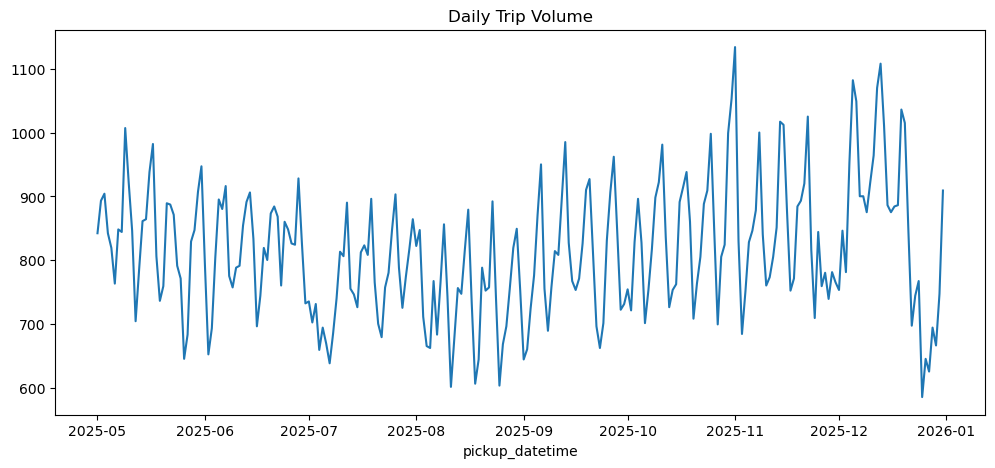

In [79]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
daily_trips = df.groupby(df["pickup_datetime"].dt.date).size()
daily_trips.plot(figsize=(12,5), title="Daily Trip Volume")

<Axes: title={'center': 'Trips by Hour'}, xlabel='hour'>

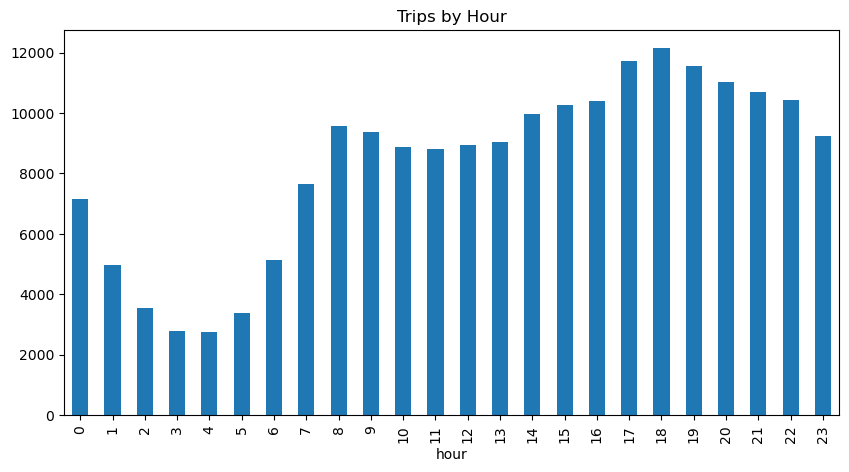

In [80]:
df["hour"] = df["pickup_datetime"].dt.hour
df["hour"].value_counts().sort_index().plot(
    kind="bar", figsize=(10,5), title="Trips by Hour"
)

# 4. Trip Characteristics

<Axes: title={'center': 'Trips by Day of Week'}, xlabel='day'>

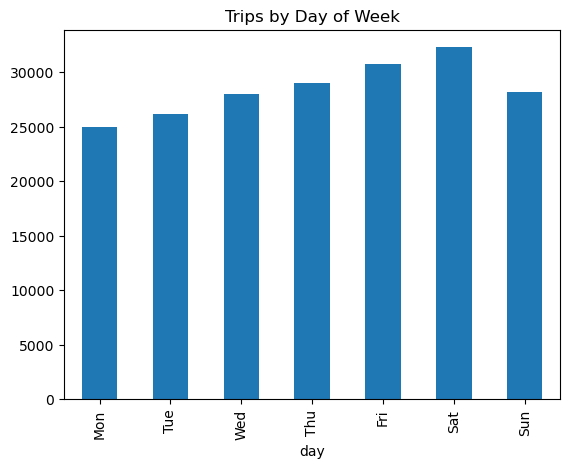

In [87]:
day_map = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}
df["day"] = df["day_of_week"].map(day_map)
df["day"].value_counts().reindex(
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
).plot(kind="bar", title="Trips by Day of Week")

In [92]:
df["trip_distance"].describe()

count    199421.000000
mean          5.103735
std         127.150671
min           0.000000
25%           1.450000
50%           2.780000
75%           5.980000
max       56667.920000
Name: trip_distance, dtype: float64

<Axes: >

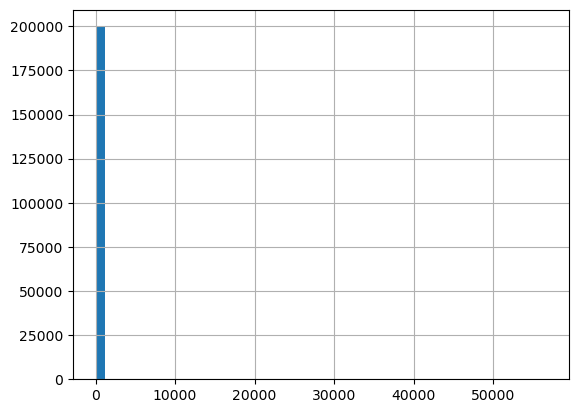

In [89]:
df["trip_distance"].hist(bins=50)

In [91]:
df["fare_amount"].describe()

count    199421.000000
mean         26.013639
std          25.016585
min        -172.400000
25%          11.660000
50%          18.740000
75%          31.310000
max         785.040000
Name: fare_amount, dtype: float64

<Axes: >

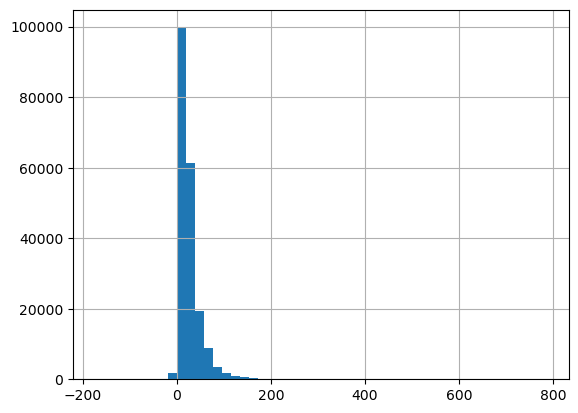

In [90]:
df["fare_amount"].hist(bins=50)

<Axes: title={'center': 'Fare vs Distance'}, xlabel='trip_distance', ylabel='fare_amount'>

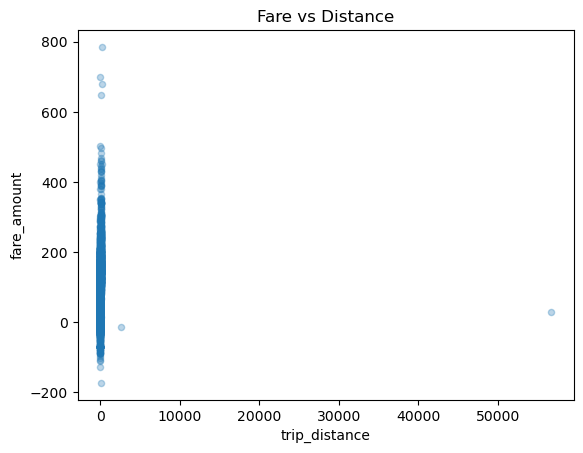

In [94]:
# distance vs fare
df.plot.scatter(
    x="trip_distance",
    y="fare_amount",
    alpha=0.3,
    title="Fare vs Distance"
)

In [95]:
df["trip_duration_min"] = (
    pd.to_datetime(df["dropoff_datetime"]) - df["pickup_datetime"]
).dt.total_seconds() / 60

df["trip_duration_min"].describe()

count    199421.000000
mean         19.945265
std          16.144001
min           0.033333
25%           9.800000
50%          16.016667
75%          25.566667
max        1438.483333
Name: trip_duration_min, dtype: float64

In [96]:
df["speed_mph"] = df["trip_distance"] / (df["trip_duration_min"] / 60)
df["speed_mph"].describe()

count    199421.000000
mean         13.697854
std         294.682485
min           0.000000
25%           8.271845
50%          11.031193
75%          15.682274
max      130772.123077
Name: speed_mph, dtype: float64

# 5. Weather Impact

In [125]:
df["precipitation_sum"].describe()

count    199347.000000
mean          3.272877
std           7.310975
min           0.000000
25%           0.000000
50%           0.100000
75%           3.000000
max          66.600000
Name: precipitation_sum, dtype: float64

<Axes: title={'center': 'Trips: Rain vs No Rain'}, xlabel='is_raining'>

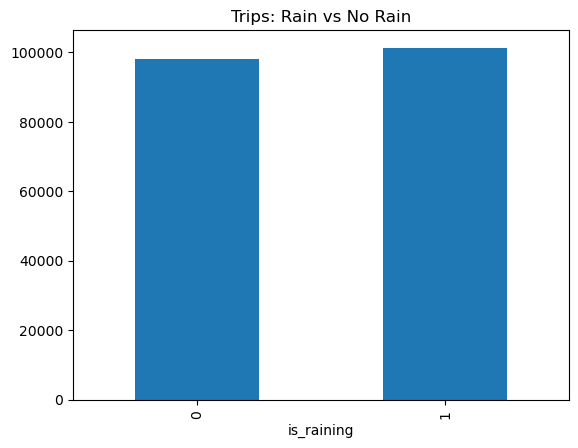

In [100]:
df["is_raining"] = (df["precipitation_sum"] > 0).astype(int)
df.groupby("is_raining").size().plot(kind="bar", title="Trips: Rain vs No Rain")

<Axes: title={'center': 'Trips by Temperature'}, xlabel='temperature_mean'>

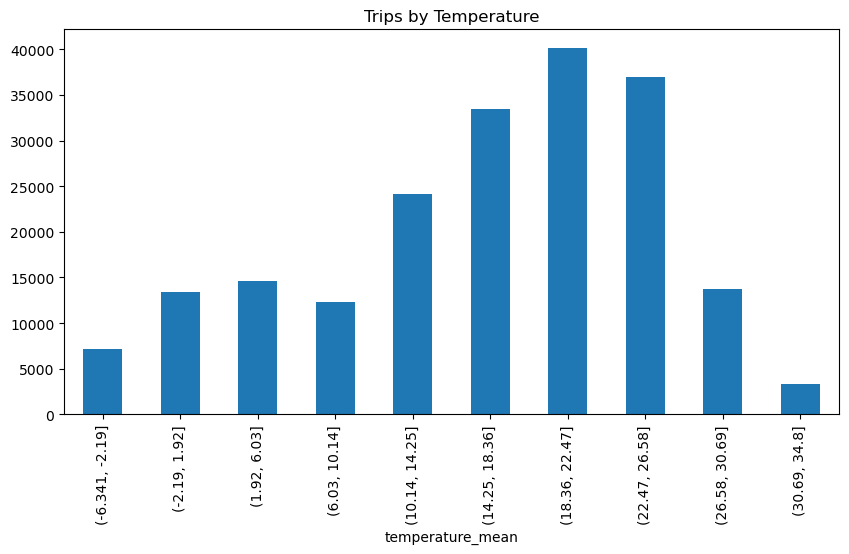

In [105]:
df.groupby(pd.cut(df["temperature_mean"], bins=10), observed=True).size().plot(
    kind="bar", figsize=(10,5), title="Trips by Temperature",
)

# 6. Location Analysis

<Axes: title={'center': 'Trips by Borough'}, xlabel='borough'>

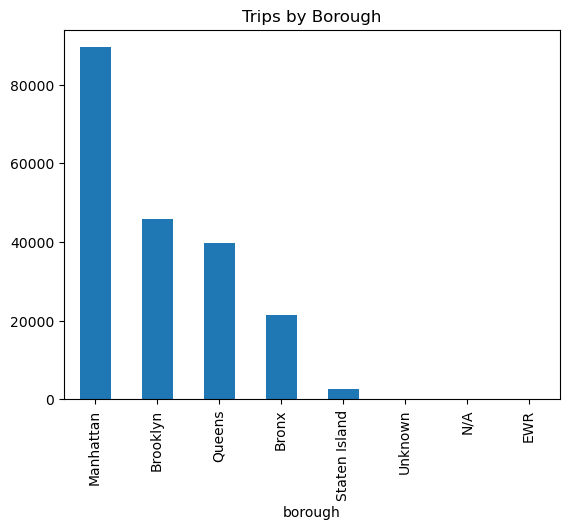

In [106]:
df["borough"].value_counts().plot(kind="bar", title="Trips by Borough")

In [120]:
top_zones = (df.groupby("zone").size().sort_values(ascending=False).head(10))
top_zones.plot(kind="barh", figsize=(10,6), title="Top 10 Pickup Zones")

zone
LaGuardia Airport            4323
JFK Airport                  4227
Midtown Center               3267
Times Sq/Theatre District    3029
East Village                 2746
Upper East Side South        2716
East Chelsea                 2630
Union Sq                     2497
Upper East Side North        2403
Midtown East                 2381
dtype: int64

# 7. Correlation Analysis

<Axes: >

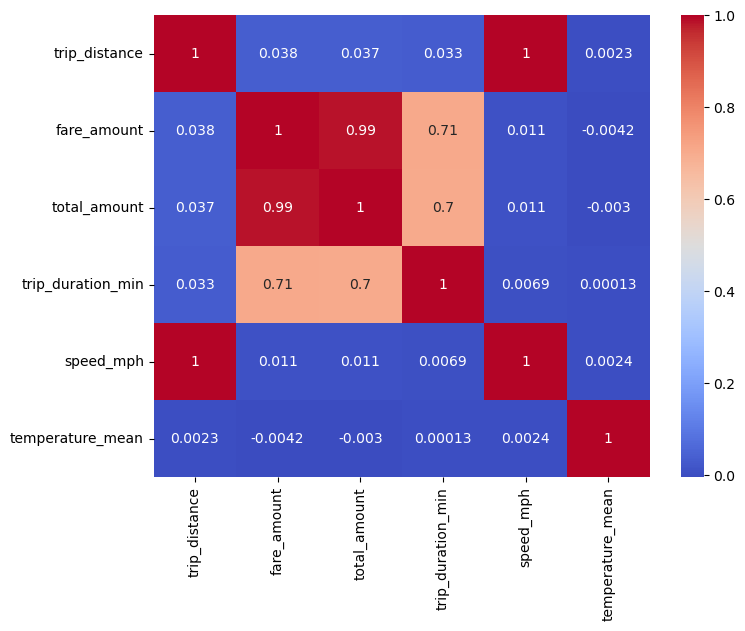

In [108]:
numeric_cols = [
    "trip_distance", "fare_amount", "total_amount",
    "trip_duration_min", "speed_mph", "temperature_mean"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")